## Dashboard de Calidad de Datos
---

## Objetivo

Construir un dashboard simple que permita analizar la calidad de los datos. Basado del ejemplo de python dado en clase.

## Consigna

A partir del dataset trabajado en clase, deberán desarrollar un **dashboard en Python (Google Colab)** que muestre métricas básicas de calidad de datos.

## Requerimientos

El dashboard debe incluir:
* **Completitud** (registros no nulos / total de registros)
* **Porcentaje de duplicados** (registros duplicados / total de registros)
* **Gráficos**:
    * Evolución de la completitud
    * Evolución del porcentaje de duplicados
* **KPIs del último período**:
    * Completitud
     % de duplicados
* **Alertas simples**:
    * Completitud < 90%
    * % duplicados > 10%

## Análisis

Responder brevemente:
1. ¿Cómo evoluciona la calidad de los datos?
2. ¿Qué problema es más importante?
3. ¿Qué propondrían para mejorar?

## Entrega

* Notebook en Google Colab
* Gráficos generados
* Respuestas al análisis

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [113]:
# Aterrizajes y despegues procesados por la Administración Nacional de Aviación Civil (ANAC) en el año 2025
df = pd.read_csv('aterrizajes-despegues-anac-2025.csv', sep=';')
df.head()

,Fecha UTC,Hora UTC,Clase de Vuelo (todos los vuelos),Clasificación Vuelo,Tipo de Movimiento,Aeropuerto,Origen / Destino,Aerolinea Nombre,Aeronave,Pasajeros,PAX,Calidad dato
0,01/01/2025,0:00,Regular,Doméstico,Aterrizaje,BAR,EZE,FB LÍNEAS AÉREAS - FLYBONDI,BO-737-8Q8,"167,00","83,50",DEFINITIVO
1,01/01/2025,0:03,Regular,Internacional,Despegue,EZE,KATL,DELTA AIRLINES,0,"281,00","281,00",DEFINITIVO
2,01/01/2025,0:06,Regular,Doméstico,Aterrizaje,SAL,NEU,JETSMART AIRLINES S.A.,AIB-A320-232,"174,00","87,00",DEFINITIVO
3,01/01/2025,0:07,Regular,Doméstico,Aterrizaje,CBA,BAR,FB LÍNEAS AÉREAS - FLYBONDI,BO-737-8U3,"83,00","41,50",DEFINITIVO
4,01/01/2025,0:07,Regular,Internacional,Despegue,AER,SCEL,LATAM AIRLINES GROUP S.A.(exLAN AIRLINE),0,"162,00","162,00",DEFINITIVO


In [98]:
# Convertir la columna Fecha UTC a tipo datetime
df['Fecha UTC'] = pd.to_datetime(df['Fecha UTC'], format='%d/%m/%Y')

In [99]:
# Crear una columna con el mes
df['mes'] = df['Fecha UTC'].dt.month

In [100]:
# Contar registros por mes
conteo = df.groupby('mes').size()

In [101]:
# Contar duplicados por mes (duplicados en toda la fila)
duplicados = df[df.duplicated()].groupby('mes').size()

In [102]:
# Reemplazar ceros por NaN en todas las columnas numéricas
df = df.replace('0', np.nan)

In [103]:
# Contar nulos por mes (si alguna columna tiene nulos en ese registro)
nulos = df[df.isnull().any(axis=1)].groupby('mes').size()

In [104]:
# Unir todo en un DataFrame resumen
resumen = pd.DataFrame({
    "total_registros": conteo,
    "duplicados": duplicados,
    "nulos": nulos
}).fillna(0).astype(int)

# 1. Dataset generado
resumen

,total_registros,duplicados,nulos
mes,,,
1,49472,24,24080
2,45539,30,23438
3,51537,36,26530
4,49756,57,27820
5,46941,46,26203
6,45695,115,25177
7,52174,79,27127
8,52116,121,27685
9,50244,78,26687


In [105]:
# 2. KPIs de calidad
resumen['completitud'] = 1 - (resumen['nulos'] / resumen['total_registros'])
resumen['pct_duplicados'] = resumen['duplicados'] / resumen['total_registros']
resumen

,total_registros,duplicados,nulos,completitud,pct_duplicados
mes,,,,,
1,49472,24,24080,0.513260,0.000485
2,45539,30,23438,0.485320,0.000659
3,51537,36,26530,0.485224,0.000699
4,49756,57,27820,0.440871,0.001146
5,46941,46,26203,0.441789,0.000980
6,45695,115,25177,0.449021,0.002517
7,52174,79,27127,0.480067,0.001514
8,52116,121,27685,0.468781,0.002322
9,50244,78,26687,0.468852,0.001552


In [106]:
# 3. KPI actuales (último período)
ultimo = resumen.iloc[-1]

print('KPIs actuales:')
print(f'Completitud: {ultimo['completitud']:.2%}')
print(f'% Duplicados: {ultimo['pct_duplicados']:.2%}')

KPIs actuales:
Completitud: 44.68%
% Duplicados: 0.15%


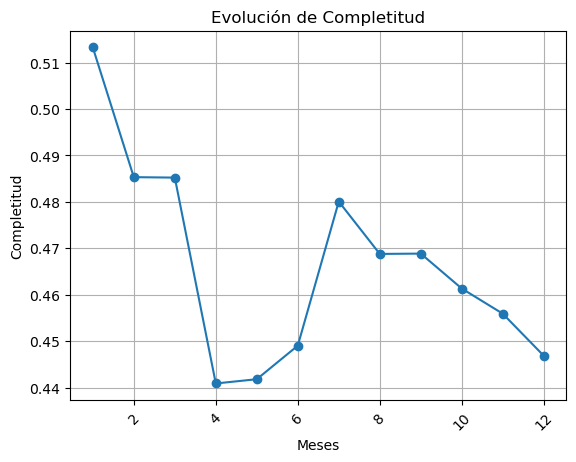

In [107]:
# 4. Dashboard (gráficos)
plt.figure()
plt.plot(resumen.index, resumen['completitud'], marker='o')
plt.title('Evolución de Completitud')
plt.xlabel('Meses')
plt.ylabel('Completitud')
plt.xticks(rotation=45)
plt.grid()
plt.show()

**Se observa una caída marcada en los primeros meses, una recuperación parcial hacia la mitad del año y luego vuelve a descender**

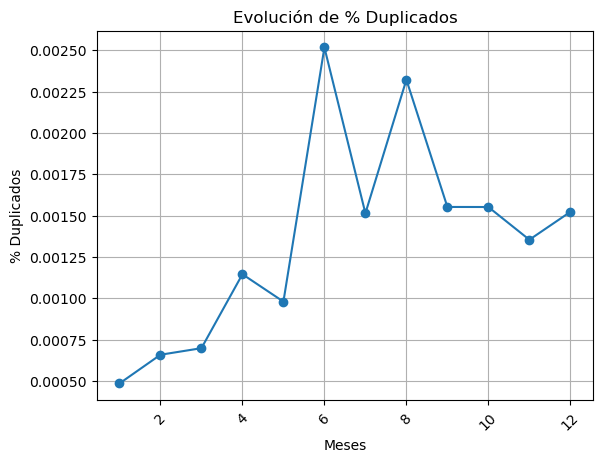

In [109]:
plt.figure()
plt.plot(resumen.index, resumen['pct_duplicados'], marker='o')
plt.title('Evolución de % Duplicados')
plt.xlabel('Meses')
plt.ylabel('% Duplicados')
plt.xticks(rotation=45)
plt.grid()
plt.show()

**Se observa que los duplicados aumentan con fuerza hasta el mes 6 y luego se estabilizan en valores intermedios**

In [111]:
# 5. Alertas simples
umbral_completitud = 0.9
umbral_duplicados = 0.1

print('🚨 Alertas:')

if ultimo['completitud'] < umbral_completitud:
    print('⚠️ Baja completitud detectada')
else:
    print('✅ Completitud OK')

if ultimo['pct_duplicados'] > umbral_duplicados:
    print('⚠️ Alto nivel de duplicados')
else:
    print('✅ Duplicados OK')

🚨 Alertas:
⚠️ Baja completitud detectada
✅ Duplicados OK


**Problema más importante**:  
El incremento de duplicados es más crítico, porque afecta directamente la confiabilidad y consistencia de los datos, incluso si la completitud mejora parcialmente.

**Propuesta de mejora**. Implementar controles automáticos de calidad:
* Normalización y deduplicación (es una técnica de compresión que optimiza el almacenamiento al eliminar copias redundantes, guardando solo una instancia única de cada bloque o archivo) periódica.
* Monitoreo continuo con alertas tempranas.
* Revisión de procesos de carga para asegurar completitud estable.